## PCA
transformacija vise dimenzija u 2

In [27]:
import pandas as pd

In [28]:
df = pd.read_csv('./data/iris.csv')

In [29]:
df.head()

,Sepal_Length,Sepal_Width,Petal_Length,Petal_Width,Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [30]:
from sklearn.decomposition import PCA

In [31]:
pca = PCA()

In [32]:
X = df.drop('Species', axis=1)

In [33]:
y = df['Species']

In [34]:
from sklearn.preprocessing import StandardScaler

In [35]:
scaler = StandardScaler()

In [36]:
x_scaled = scaler.fit_transform(X)

In [37]:
x_scaled = pd.DataFrame(x_scaled, columns=X.columns)

In [38]:
x_scaled

,Sepal_Length,Sepal_Width,Petal_Length,Petal_Width
0,-0.900681,1.019004,-1.340227,-1.315444
1,-1.143017,-0.131979,-1.340227,-1.315444
2,-1.385353,0.328414,-1.397064,-1.315444
3,-1.506521,0.098217,-1.283389,-1.315444
4,-1.021849,1.249201,-1.340227,-1.315444
...,...,...,...,...
145,1.038005,-0.131979,0.819596,1.448832
146,0.553333,-1.282963,0.705921,0.922303
147,0.795669,-0.131979,0.819596,1.053935
148,0.432165,0.788808,0.933271,1.448832


In [39]:
pca.fit(x_scaled)

,n_components,None
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [40]:
x_pca = pca.transform(x_scaled)

In [41]:
x_names = [f'pca_{i}' for i in range(len(X.columns))]
x_names

['pca_0', 'pca_1', 'pca_2', 'pca_3']

In [42]:
x_pca

array([[-2.26470281e+00,  4.80026597e-01,  1.27706022e-01,
        -2.41682039e-02],
       [-2.08096115e+00, -6.74133557e-01,  2.34608854e-01,
        -1.03006775e-01],
       [-2.36422905e+00, -3.41908024e-01, -4.42014848e-02,
        -2.83770534e-02],
       [-2.29938422e+00, -5.97394508e-01, -9.12901063e-02,
         6.59555596e-02],
       [-2.38984217e+00,  6.46835383e-01, -1.57381957e-02,
         3.59228133e-02],
       [-2.07563095e+00,  1.48917752e+00, -2.69682944e-02,
        -6.60818022e-03],
       [-2.44402884e+00,  4.76441976e-02, -3.35470401e-01,
         3.67755572e-02],
       [-2.23284716e+00,  2.23148073e-01,  8.86954979e-02,
         2.46120962e-02],
       [-2.33464048e+00, -1.11532768e+00, -1.45076864e-01,
         2.68592208e-02],
       [-2.18432817e+00, -4.69013561e-01,  2.53765567e-01,
         3.98992877e-02],
       [-2.16631010e+00,  1.04369065e+00,  2.68681102e-01,
        -1.67313672e-02],
       [-2.32613087e+00,  1.33078335e-01, -9.37592444e-02,
      

In [43]:
x_pca = pd.DataFrame(x_pca,columns=x_names)

In [44]:
x_pca

,pca_0,pca_1,pca_2,pca_3
0,-2.264703,0.480027,0.127706,-0.024168
1,-2.080961,-0.674134,0.234609,-0.103007
2,-2.364229,-0.341908,-0.044201,-0.028377
3,-2.299384,-0.597395,-0.091290,0.065956
4,-2.389842,0.646835,-0.015738,0.035923
...,...,...,...,...
145,1.870503,0.386966,-0.256274,-0.389257
146,1.564580,-0.896687,0.026371,-0.220192
147,1.521170,0.269069,-0.180178,-0.119171
148,1.372788,1.011254,-0.933395,-0.026129


In [45]:
import matplotlib.pyplot as plt

<BarContainer object of 4 artists>

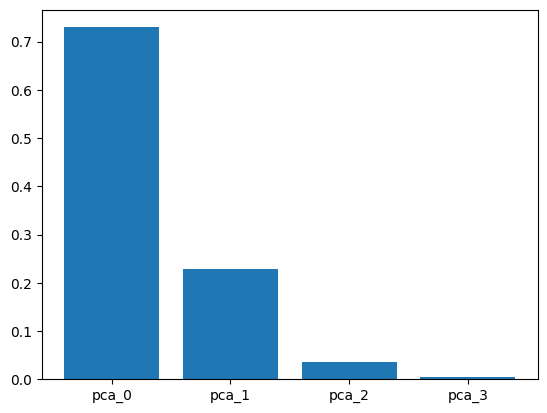

In [46]:
plt.bar(x_names,pca.explained_variance_ratio_)

In [47]:
import numpy as np

In [49]:
cumulative_variance_ratio = np.cumsum(pca.explained_variance_ratio_)

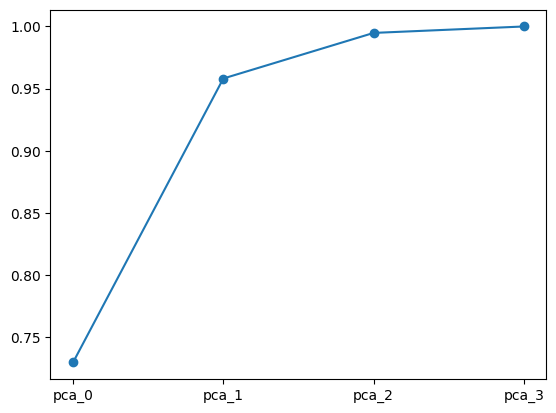

In [52]:
plt.plot(x_names,cumulative_variance_ratio,marker='o')

dakle dovoljna su nam 2 atributa

C:\Users\Administrator\AppData\Local\Temp\ipykernel_3312\3786747111.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='best')


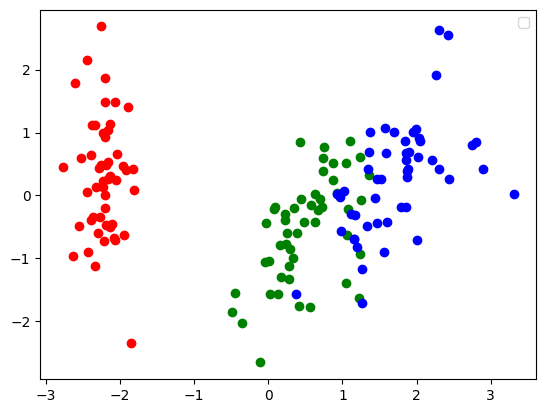

In [60]:
class_names = y.unique()
colors = ['red','green','blue']
for i,class_name in enumerate(class_names):
    class_intance = x_pca.iloc[y[y == class_name].index]
    plt.scatter(class_intance['pca_0'], class_intance['pca_1'], c=colors[i])

plt.legend(loc='best')

## SVM

In [61]:
from sklearn.svm import SVC

In [62]:
svc = SVC()

In [64]:
from sklearn.model_selection import train_test_split, GridSearchCV

In [65]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y)

In [66]:
scaler = StandardScaler()

In [67]:
X_train = scaler.fit_transform(X_train)

In [68]:
X_test = scaler.transform(X_test)

In [74]:
params = [{'C': [2**i for i in range(-3,3)],
          'kernel': ['poly'],
          'gamma': np.arange(0,1,0.1)},
          {'C': [2**i for i in range(-3,3)],
            'kernel': ['linear']}]

model = GridSearchCV(SVC(),params, cv=5, scoring='accuracy', verbose=4)

In [75]:
model.fit(X_train, y_train)

Fitting 5 folds for each of 66 candidates, totalling 330 fits
[CV 1/5] END ...C=0.125, gamma=0.0, kernel=poly;, score=0.333 total time=   0.0s
[CV 2/5] END ...C=0.125, gamma=0.0, kernel=poly;, score=0.333 total time=   0.0s
[CV 3/5] END ...C=0.125, gamma=0.0, kernel=poly;, score=0.333 total time=   0.0s
[CV 4/5] END ...C=0.125, gamma=0.0, kernel=poly;, score=0.333 total time=   0.0s
[CV 5/5] END ...C=0.125, gamma=0.0, kernel=poly;, score=0.333 total time=   0.0s
[CV 1/5] END ...C=0.125, gamma=0.1, kernel=poly;, score=0.619 total time=   0.0s
[CV 2/5] END ...C=0.125, gamma=0.1, kernel=poly;, score=0.333 total time=   0.0s
[CV 3/5] END ...C=0.125, gamma=0.1, kernel=poly;, score=0.571 total time=   0.0s
[CV 4/5] END ...C=0.125, gamma=0.1, kernel=poly;, score=0.524 total time=   0.0s
[CV 5/5] END ...C=0.125, gamma=0.1, kernel=poly;, score=0.571 total time=   0.0s
[CV 1/5] END ...C=0.125, gamma=0.2, kernel=poly;, score=0.857 total time=   0.0s
[CV 2/5] END ...C=0.125, gamma=0.2, kernel=poly

,estimator,SVC()
,param_grid,"[{'C': [0.125, 0.25, ...], 'gamma': array([0. , 0....7, 0.8, 0.9]), 'kernel': ['poly']}, {'C': [0.125, 0.25, ...], 'kernel': ['linear']}]"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,4
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,1


In [76]:
print(model.best_estimator_)

SVC(C=1, kernel='linear')


In [77]:
print(model.best_estimator_.n_support_)

[ 2 13 10]


In [78]:
y_pred = model.best_estimator_.predict(X_test)

In [82]:
from sklearn.metrics import accuracy_score

In [83]:
accuracy_score(y_test, y_pred)

0.9777777777777777